# Notebook 4 — Classical ML Models
**Project:** Stock Price Movement Prediction Using Financial News Sentiment Analysis and Machine Learning  
**Student:** Venkata Kiran Kumar Mullapudi (16200362) | **Ethics:** P193120

This notebook trains and evaluates three classical ML models across 4 ablation feature configurations:
- Logistic Regression (baseline)
- Support Vector Machine (RBF kernel, grid search)
- Random Forest (200 trees, feature importance)

Metrics: Accuracy, F1, Precision, Recall, AUC-ROC

> **CPU only — GPU OFF to save quota**

In [1]:
# Cell 1 — Imports
import os, glob, pickle, warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import SVC
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics         import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11

OUTPUT_DIR = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CONFIGS   = ['price_only', 'price_vader', 'price_finbert', 'price_both']
MODELS    = ['Logistic Regression', 'SVM', 'Random Forest']
RANDOM_STATE = 42

print('All imports OK')

All imports OK


In [2]:
# Cell 2 — Load feature datasets from NB3
def find_file(filename):
    for pattern in [f'{OUTPUT_DIR}/{filename}', f'/kaggle/input/**/{filename}']:
        m = glob.glob(pattern, recursive=True)
        if m: return m[0]
    return None

pkl_path = find_file('feature_datasets.pkl')
if not pkl_path:
    raise FileNotFoundError('feature_datasets.pkl not found — link NB3 output via + Add Data')

with open(pkl_path, 'rb') as f:
    datasets = pickle.load(f)

print('Loaded feature datasets:')
for name, d in datasets.items():
    print(f'  {name:20s}  train={d["X_train"].shape}  val={d["X_val"].shape}  test={d["X_test"].shape}')

# Combine val into train for final evaluation (use val for hyperparam search only)
# For classical ML we use train+val to fit, test to evaluate
# But we keep them separate for grid search CV on train only
print('\nLabel counts:')
d0 = datasets['price_only']
print(f'  Train: Up={d0["y_train"].sum()} ({100*d0["y_train"].mean():.1f}%)  Down={(d0["y_train"]==0).sum()}')
print(f'  Val  : Up={d0["y_val"].sum()}   ({100*d0["y_val"].mean():.1f}%)  Down={(d0["y_val"]==0).sum()}')
print(f'  Test : Up={d0["y_test"].sum()}  ({100*d0["y_test"].mean():.1f}%)  Down={(d0["y_test"]==0).sum()}')

Loaded feature datasets:
  price_only            train=(8790, 15)  val=(1880, 15)  test=(1890, 15)
  price_vader           train=(8790, 20)  val=(1880, 20)  test=(1890, 20)
  price_finbert         train=(8790, 23)  val=(1880, 23)  test=(1890, 23)
  price_both            train=(8790, 28)  val=(1880, 28)  test=(1890, 28)

Label counts:
  Train: Up=4680 (53.2%)  Down=4110
  Val  : Up=948   (50.4%)  Down=932
  Test : Up=1024  (54.2%)  Down=866


In [3]:
# Cell 3 — Define evaluation function
def evaluate(model, X_test, y_test, model_name, config_name):
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
        # Normalise to [0,1]
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-9)
    else:
        y_prob = y_pred.astype(float)

    return {
        'Model'    : model_name,
        'Config'   : config_name,
        'Accuracy' : round(accuracy_score(y_test, y_pred) * 100, 2),
        'F1'       : round(f1_score(y_test, y_pred, zero_division=0) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0) * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred, zero_division=0) * 100, 2),
        'AUC_ROC'  : round(roc_auc_score(y_test, y_prob) * 100, 2),
        'y_prob'   : y_prob,
        'y_pred'   : y_pred,
    }

print('Evaluation function defined.')

Evaluation function defined.


In [4]:
# Cell 4 — Logistic Regression (all 4 configs)
print('=== Training Logistic Regression ===')
lr_results = []

for config in CONFIGS:
    d = datasets[config]
    # Combine train+val for fitting
    X_fit = np.vstack([d['X_train'], d['X_val']])
    y_fit = np.concatenate([d['y_train'], d['y_val']])

    t0  = time.time()
    lr  = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs')
    lr.fit(X_fit, y_fit)
    elapsed = time.time() - t0

    res = evaluate(lr, d['X_test'], d['y_test'], 'Logistic Regression', config)
    res['train_time'] = round(elapsed, 2)
    res['model_obj']  = lr
    lr_results.append(res)

    print(f'  {config:20s}  Acc={res["Accuracy"]:5.2f}%  F1={res["F1"]:5.2f}%  '
          f'AUC={res["AUC_ROC"]:5.2f}%  time={elapsed:.1f}s')

print('\nLogistic Regression complete.')

=== Training Logistic Regression ===
  price_only            Acc=53.60%  F1=68.85%  AUC=49.38%  time=0.0s
  price_vader           Acc=53.07%  F1=66.69%  AUC=49.41%  time=0.0s
  price_finbert         Acc=51.22%  F1=61.90%  AUC=50.06%  time=0.0s
  price_both            Acc=51.22%  F1=60.36%  AUC=49.97%  time=0.0s

Logistic Regression complete.


In [5]:
# Cell 5 — SVM with grid search (all 4 configs)
print('=== Training SVM (RBF kernel + grid search) ===')
print('Note: Grid search on 8,790 samples may take 10-20 min per config...')
svm_results = []
best_svm_params = {}

# Reduced grid for speed — covers key ranges
param_grid = {
    'C'    : [0.1, 1.0, 10.0],
    'gamma': ['scale', 0.01, 0.001]
}

for config in CONFIGS:
    d = datasets[config]
    X_fit = np.vstack([d['X_train'], d['X_val']])
    y_fit = np.concatenate([d['y_train'], d['y_val']])

    t0 = time.time()
    cv = StratifiedKFold(n_splits=3, shuffle=False)  # time-ordered — no shuffle
    gs = GridSearchCV(
        SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
        param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0
    )
    gs.fit(X_fit, y_fit)
    elapsed = time.time() - t0

    best_params = gs.best_params_
    best_svm_params[config] = best_params

    res = evaluate(gs.best_estimator_, d['X_test'], d['y_test'], 'SVM', config)
    res['train_time']   = round(elapsed, 2)
    res['best_params']  = best_params
    res['model_obj']    = gs.best_estimator_
    svm_results.append(res)

    print(f'  {config:20s}  Acc={res["Accuracy"]:5.2f}%  F1={res["F1"]:5.2f}%  '
          f'AUC={res["AUC_ROC"]:5.2f}%  time={elapsed:.0f}s  params={best_params}')

print('\nSVM complete.')
print('\nBest SVM hyperparameters per config:')
for config, params in best_svm_params.items():
    print(f'  {config:20s} : C={params["C"]}, gamma={params["gamma"]}')

=== Training SVM (RBF kernel + grid search) ===
Note: Grid search on 8,790 samples may take 10-20 min per config...
  price_only            Acc=54.18%  F1=70.28%  AUC=50.15%  time=192s  params={'C': 0.1, 'gamma': 0.001}
  price_vader           Acc=54.18%  F1=70.28%  AUC=50.07%  time=197s  params={'C': 0.1, 'gamma': 0.001}
  price_finbert         Acc=54.18%  F1=70.28%  AUC=50.37%  time=208s  params={'C': 0.1, 'gamma': 0.001}
  price_both            Acc=54.18%  F1=70.28%  AUC=49.92%  time=226s  params={'C': 0.1, 'gamma': 0.001}

SVM complete.

Best SVM hyperparameters per config:
  price_only           : C=0.1, gamma=0.001
  price_vader          : C=0.1, gamma=0.001
  price_finbert        : C=0.1, gamma=0.001
  price_both           : C=0.1, gamma=0.001


In [6]:
# Cell 6 — Random Forest (all 4 configs)
print('=== Training Random Forest (200 trees) ===')
rf_results = []
rf_models  = {}

for config in CONFIGS:
    d = datasets[config]
    X_fit = np.vstack([d['X_train'], d['X_val']])
    y_fit = np.concatenate([d['y_train'], d['y_val']])

    t0 = time.time()
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=None,
        min_samples_split=5, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    rf.fit(X_fit, y_fit)
    elapsed = time.time() - t0

    res = evaluate(rf, d['X_test'], d['y_test'], 'Random Forest', config)
    res['train_time'] = round(elapsed, 2)
    res['model_obj']  = rf
    rf_results.append(res)
    rf_models[config] = rf

    print(f'  {config:20s}  Acc={res["Accuracy"]:5.2f}%  F1={res["F1"]:5.2f}%  '
          f'AUC={res["AUC_ROC"]:5.2f}%  time={elapsed:.1f}s')

print('\nRandom Forest complete.')

=== Training Random Forest (200 trees) ===
  price_only            Acc=51.16%  F1=56.65%  AUC=51.62%  time=5.1s
  price_vader           Acc=51.43%  F1=56.29%  AUC=51.23%  time=5.2s
  price_finbert         Acc=50.48%  F1=51.80%  AUC=50.13%  time=4.9s
  price_both            Acc=49.63%  F1=50.21%  AUC=49.88%  time=5.3s

Random Forest complete.


In [7]:
# Cell 7 — Compile full results table
all_results = lr_results + svm_results + rf_results

# Build clean summary DataFrame
summary_cols = ['Model','Config','Accuracy','F1','Precision','Recall','AUC_ROC','train_time']
results_df = pd.DataFrame([{k: r[k] for k in summary_cols} for r in all_results])

print('=== FULL RESULTS TABLE — Classical ML Models ===')
print(results_df.to_string(index=False))

# Ablation: marginal gain from adding sentiment
print('\n=== ABLATION — Accuracy gain: price_only → price_both ===')
for model in MODELS:
    sub = results_df[results_df['Model'] == model]
    base = sub[sub['Config']=='price_only']['Accuracy'].values[0]
    both = sub[sub['Config']=='price_both']['Accuracy'].values[0]
    gain = both - base
    print(f'  {model:20s}: {base:.2f}% → {both:.2f}%  (gain: {gain:+.2f}pp)')

print('\n=== ABLATION — FinBERT vs VADER (price_finbert vs price_vader) ===')
for model in MODELS:
    sub = results_df[results_df['Model'] == model]
    vader   = sub[sub['Config']=='price_vader']['Accuracy'].values[0]
    finbert = sub[sub['Config']=='price_finbert']['Accuracy'].values[0]
    diff    = finbert - vader
    print(f'  {model:20s}: VADER={vader:.2f}%  FinBERT={finbert:.2f}%  (diff: {diff:+.2f}pp)')

# Save results
results_df.to_csv(f'{OUTPUT_DIR}/classical_ml_results.csv', index=False)
print('\nSaved: classical_ml_results.csv')

=== FULL RESULTS TABLE — Classical ML Models ===
              Model        Config  Accuracy    F1  Precision  Recall  AUC_ROC  train_time
Logistic Regression    price_only     53.60 68.85      54.10   94.63    49.38        0.03
Logistic Regression   price_vader     53.07 66.69      54.18   86.72    49.41        0.02
Logistic Regression price_finbert     51.22 61.90      53.65   73.14    50.06        0.02
Logistic Regression    price_both     51.22 60.36      53.92   68.55    49.97        0.03
                SVM    price_only     54.18 70.28      54.18  100.00    50.15      192.19
                SVM   price_vader     54.18 70.28      54.18  100.00    50.07      196.99
                SVM price_finbert     54.18 70.28      54.18  100.00    50.37      208.19
                SVM    price_both     54.18 70.28      54.18  100.00    49.92      226.02
      Random Forest    price_only     51.16 56.65      54.57   58.89    51.62        5.11
      Random Forest   price_vader     51.43 56.29  

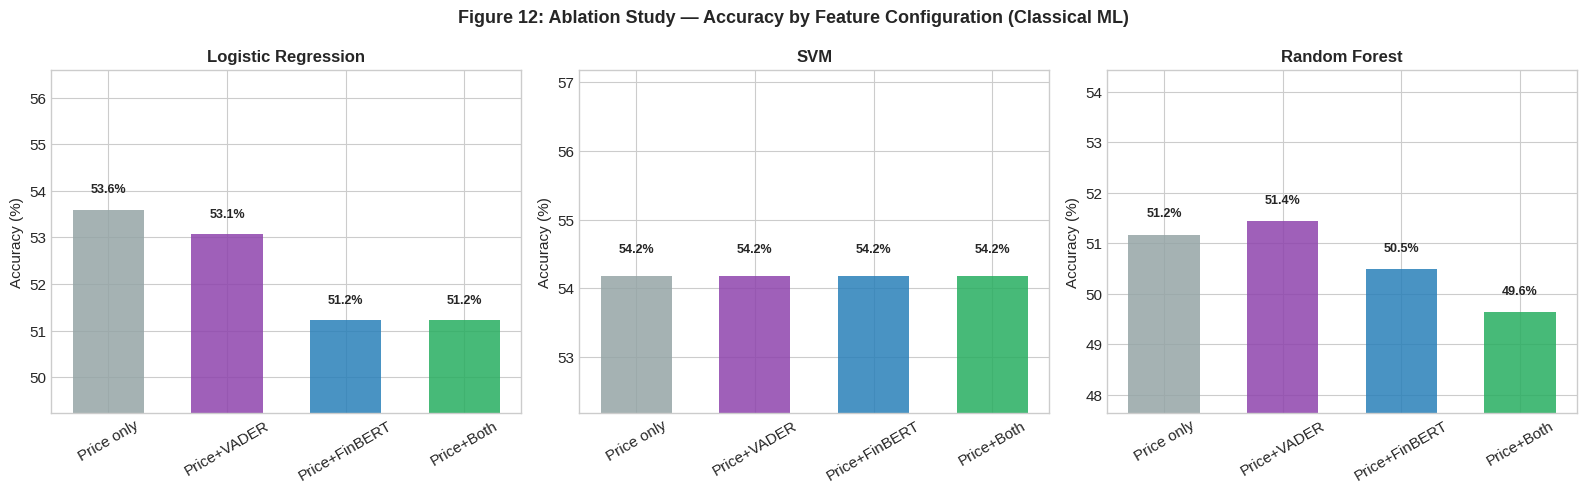

Saved: fig12_ablation_classical.png


In [8]:
# Cell 8 — Figure 12: Ablation bar chart (accuracy across configs)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
colors_cfg = ['#95a5a6','#8e44ad','#2980b9','#27ae60']
cfg_labels = ['Price only','Price+VADER','Price+FinBERT','Price+Both']

for ax, model in zip(axes, MODELS):
    sub  = results_df[results_df['Model'] == model]
    accs = [sub[sub['Config']==c]['Accuracy'].values[0] for c in CONFIGS]
    bars = ax.bar(cfg_labels, accs, color=colors_cfg, alpha=0.85, width=0.6)
    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(min(accs)-2, max(accs)+3)
    ax.tick_params(axis='x', rotation=30)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Figure 12: Ablation Study — Accuracy by Feature Configuration (Classical ML)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig12_ablation_classical.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig12_ablation_classical.png')

  Logistic Regression  best config: price_only  F1=68.85%
  SVM                  best config: price_only  F1=70.28%
  Random Forest        best config: price_only  F1=56.65%


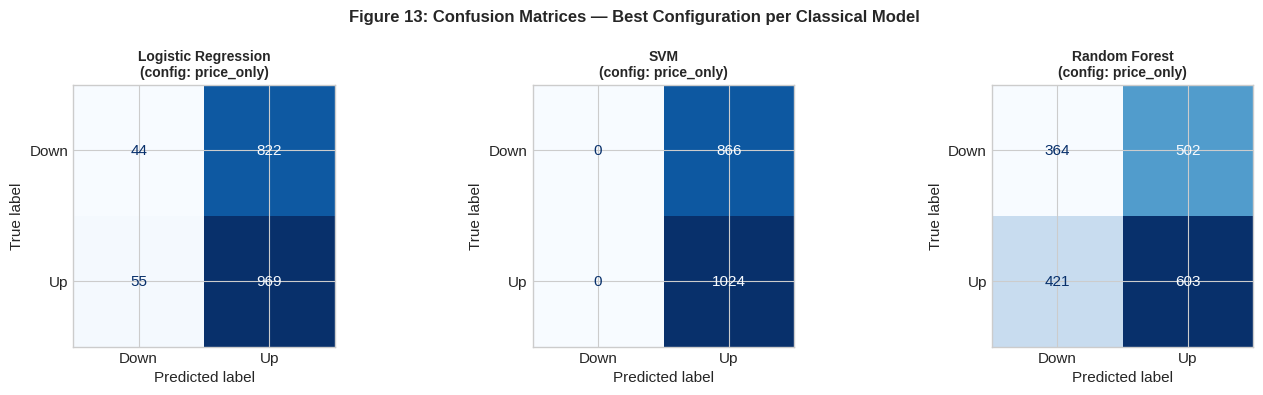

Saved: fig13_confusion_matrices.png


In [9]:
# Cell 9 — Figure 13: Confusion matrices for best config of each model
# Find best config per model (by F1)
best_configs = {}
for model in MODELS:
    sub  = results_df[results_df['Model'] == model]
    best = sub.loc[sub['F1'].idxmax()]
    best_configs[model] = best['Config']
    print(f'  {model:20s} best config: {best["Config"]}  F1={best["F1"]}%')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, model in zip(axes, MODELS):
    best_cfg = best_configs[model]
    # Get the result entry
    res_entry = [r for r in all_results if r['Model']==model and r['Config']==best_cfg][0]
    d  = datasets[best_cfg]
    cm = confusion_matrix(d['y_test'], res_entry['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down','Up'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model}\n(config: {best_cfg})', fontsize=10, fontweight='bold')

plt.suptitle('Figure 13: Confusion Matrices — Best Configuration per Classical Model',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig13_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig13_confusion_matrices.png')

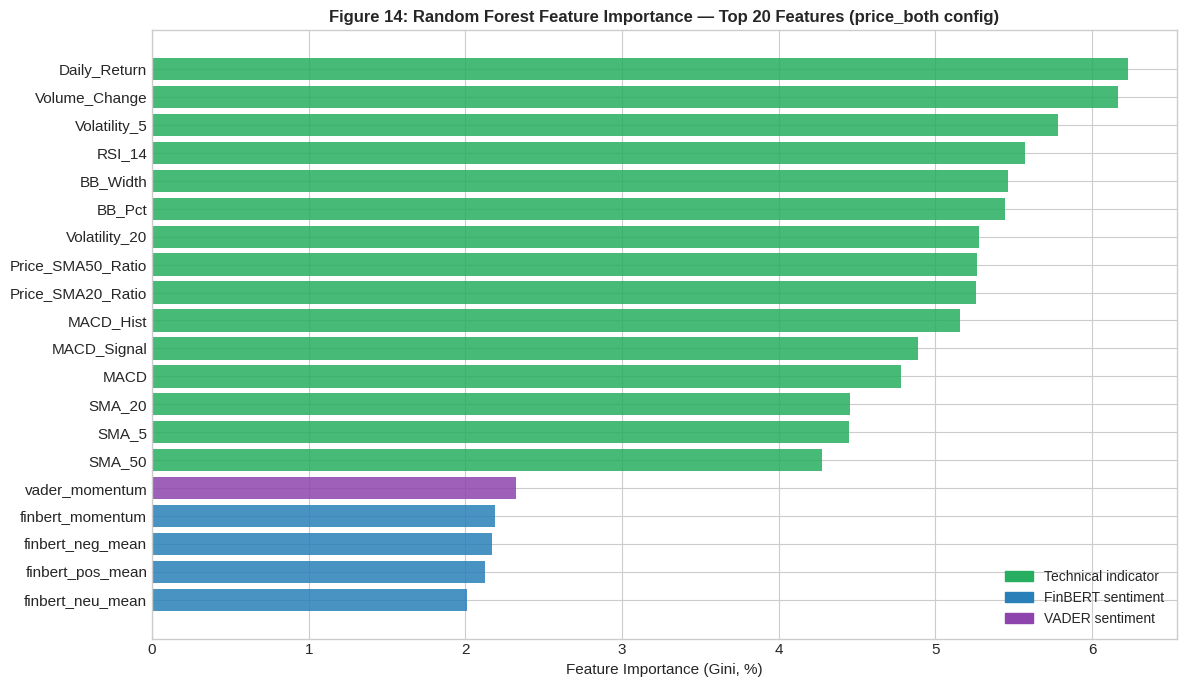

Saved: fig14_feature_importance.png

Top 15 features by importance:
          Feature  Importance
     Daily_Return    0.062309
    Volume_Change    0.061674
     Volatility_5    0.057820
           RSI_14    0.055712
         BB_Width    0.054622
           BB_Pct    0.054472
    Volatility_20    0.052780
Price_SMA50_Ratio    0.052651
Price_SMA20_Ratio    0.052597
        MACD_Hist    0.051577
      MACD_Signal    0.048880
             MACD    0.047820
           SMA_20    0.044557
            SMA_5    0.044514
           SMA_50    0.042739


In [10]:
# Cell 10 — Figure 14: Random Forest feature importance (price_both config)
rf_both   = rf_models['price_both']
feat_cols = datasets['price_both']['feature_cols']
importances = rf_both.feature_importances_

feat_imp = pd.DataFrame({'Feature': feat_cols, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=False).reset_index(drop=True)

# Colour by feature type
def feat_color(name):
    if 'finbert' in name: return '#2980b9'
    if 'vader'   in name or 'headline' in name: return '#8e44ad'
    return '#27ae60'

top20 = feat_imp.head(20)
colors = [feat_color(f) for f in top20['Feature']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20['Feature'][::-1], top20['Importance'][::-1] * 100,
               color=colors[::-1], alpha=0.85)
ax.set_xlabel('Feature Importance (Gini, %)')
ax.set_title('Figure 14: Random Forest Feature Importance — Top 20 Features (price_both config)',
             fontsize=12, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color='#27ae60', label='Technical indicator'),
    Patch(color='#2980b9', label='FinBERT sentiment'),
    Patch(color='#8e44ad', label='VADER sentiment'),
]
ax.legend(handles=legend, loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: fig14_feature_importance.png')
print('\nTop 15 features by importance:')
print(feat_imp.head(15).to_string(index=False))

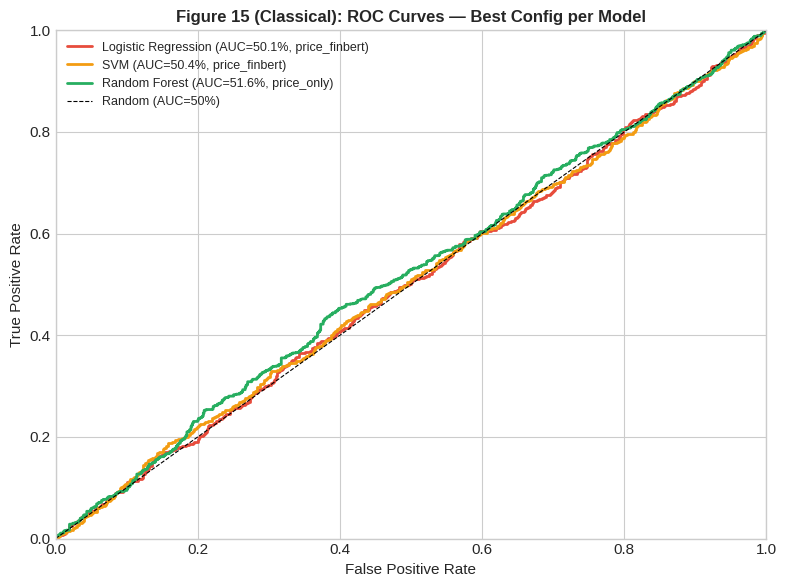

Saved: fig15_roc_classical.png


In [11]:
# Cell 11 — ROC curves for best model per config
fig, ax = plt.subplots(figsize=(8, 6))
colors_model = {'Logistic Regression': '#e74c3c', 'SVM': '#f39c12', 'Random Forest': '#27ae60'}

for model in MODELS:
    sub      = results_df[results_df['Model'] == model]
    best_cfg = sub.loc[sub['AUC_ROC'].idxmax(), 'Config']
    res_entry = [r for r in all_results if r['Model']==model and r['Config']==best_cfg][0]
    d         = datasets[best_cfg]
    fpr, tpr, _ = roc_curve(d['y_test'], res_entry['y_prob'])
    auc = sub.loc[sub['AUC_ROC'].idxmax(), 'AUC_ROC']
    ax.plot(fpr, tpr, label=f'{model} (AUC={auc:.1f}%, {best_cfg})',
            color=colors_model[model], linewidth=2)

ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random (AUC=50%)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 15 (Classical): ROC Curves — Best Config per Model', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig15_roc_classical.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig15_roc_classical.png')

In [12]:
# Cell 12 — Final summary
print('=== CLASSICAL ML FINAL SUMMARY ===')
print()

# Best overall classical model
best_row = results_df.loc[results_df['F1'].idxmax()]
print(f'Best classical model : {best_row["Model"]} ({best_row["Config"]})')
print(f'  Accuracy  : {best_row["Accuracy"]}%')
print(f'  F1        : {best_row["F1"]}%')
print(f'  Precision : {best_row["Precision"]}%')
print(f'  Recall    : {best_row["Recall"]}%')
print(f'  AUC-ROC   : {best_row["AUC_ROC"]}%')

print()
print('Full results table:')
print(results_df[['Model','Config','Accuracy','F1','Precision','Recall','AUC_ROC']].to_string(index=False))

print()
print('Figures saved: fig12, fig13, fig14, fig15')
print('=== NB4 COMPLETE ===')
print('Next: NB5 — Deep Learning (LSTM + CNN-LSTM) — GPU T4 needed')

=== CLASSICAL ML FINAL SUMMARY ===

Best classical model : SVM (price_only)
  Accuracy  : 54.18%
  F1        : 70.28%
  Precision : 54.18%
  Recall    : 100.0%
  AUC-ROC   : 50.15%

Full results table:
              Model        Config  Accuracy    F1  Precision  Recall  AUC_ROC
Logistic Regression    price_only     53.60 68.85      54.10   94.63    49.38
Logistic Regression   price_vader     53.07 66.69      54.18   86.72    49.41
Logistic Regression price_finbert     51.22 61.90      53.65   73.14    50.06
Logistic Regression    price_both     51.22 60.36      53.92   68.55    49.97
                SVM    price_only     54.18 70.28      54.18  100.00    50.15
                SVM   price_vader     54.18 70.28      54.18  100.00    50.07
                SVM price_finbert     54.18 70.28      54.18  100.00    50.37
                SVM    price_both     54.18 70.28      54.18  100.00    49.92
      Random Forest    price_only     51.16 56.65      54.57   58.89    51.62
      Random Fores